In [86]:
# Блок 1: Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import re
import warnings
import glob
import os
from pathlib import Path

warnings.filterwarnings('ignore')
print("Библиотеки загружены успешно")


Библиотеки загружены успешно


In [98]:
# Блок 2: Определение функций

def calculate_gas_thermometer_temperature(P, Pg1=771.0, Tg1=297.0, Pg2=31.3, Tg2=4.2):
    """
    Вычисление температуры по формуле газового термометра
    """
    # Отношение объемов Vcold/Vroom
    NUg = (Pg1 - Pg2) * Tg2 / (Pg2 * Tg1 - Tg2 * Pg1)
    
    # Формула для вычисления температуры
    T = NUg * P * Tg1 / ((NUg + 1) * Pg1 - P)
    return T, NUg

def he4_svp_temperature(P):
    """
    Вычисление температуры по давлению насыщенных паров гелия-4
    """
    # Преобразование Торр в Па (1 Торр = 133.32 Па)
    P_pa = P * 133.32
    
    if P > 1717.64 or P < 0.1:
        return np.nan
    
    if P <= 37.8199:
        x = np.log(P_pa) / 2.9 - 1.93103
        T = (1.392408 + 0.571753 * x + 0.166756 * x**2 + 
             0.669098 * x**3 + 0.026514 * x**4 + 0.001975 * x**5 - 
             0.017976 * x**6 + 0.005409 * x**7 + 0.013259 * x**8)
    else:
        x = np.log(P_pa) / 1.9 - 5.42105
        T = (3.146631 + 1.35765 * x + 0.413923 * x**2 + 
             0.091159 * x**3 + 0.016349 * x**4 + 0.001826 * x**5 - 
             0.004325 * x**6 - 0.004973 * x**7)
    
    return T

def read_and_process_file(filename, RQ=119.35):
    """
    Чтение и обработка одного файла данных
    ИСПРАВЛЕНИЕ: В файлах перепутаны Ux и U0
    """
    print(f"Обработка файла: {filename}")
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # Поиск строки с заголовками столбцов
    data_start_line = 0
    for i, line in enumerate(lines):
        if line.strip().startswith('t,s'):
            data_start_line = i
            break
    
    # Чтение числовых данных
    data_lines = []
    for i in range(data_start_line, len(lines)):
        line = lines[i].strip()
        if line and not line.startswith('##') and not line.startswith('t,s'):
            line = line.replace('E+', 'e+').replace('E-', 'e-')
            data_lines.append(line)
    
    # Преобразуем строки данных
    data = []
    for line in data_lines:
        parts = line.split()
        row = []
        for part in parts:
            try:
                if 'e' in part.lower():
                    row.append(float(part))
                else:
                    row.append(float(part))
            except ValueError:
                row.append(np.nan)
        data.append(row)
    
    # Создаем DataFrame
    # Согласно заголовку: t,s   E,V      U0,V        Ux,V        Ug,V     Pg,Torr  Uk,V     Pk,Torr
    # НО: В реальности Ux и U0 перепутаны местами в файлах!
    columns = ['t', 'E', 'U0', 'Ux', 'Ug', 'Pg', 'Uk', 'Pk']
    df = pd.DataFrame(data, columns=columns)
    
    # ИСПРАВЛЕНИЕ: В файлах Ux и U0 перепутаны местами
    # Поменяем их местами
    df = df.rename(columns={'U0': 'Ux_temp', 'Ux': 'U0_temp'})
    df = df.rename(columns={'Ux_temp': 'Ux', 'U0_temp': 'U0'})
    
    print(f"  Исправлено: Ux и U0 поменяны местами")
    
    # ФИЛЬТРАЦИЯ: удаляем закаливающие значения (>100 В)
    voltage_columns = ['U0', 'Ux', 'Ug', 'Uk']
    for col in voltage_columns:
        if col in df.columns:
            df = df[df[col].abs() <= 100]
    
    print(f"  Сохранено строк после фильтрации: {len(df)}")
    
    # Вычисление производных величин с ИСПРАВЛЕННЫМИ значениями
    df['TQ'] = df['U0'] / RQ / 1000  # Измерительный ток (А) - теперь с правильным U0!
    df['Rs'] = RQ * df['Ux'] / df['U0']  # Сопротивление образца (кОм) - теперь с правильными Ux и U0!
    
    # Сопротивление на минимальном токе
    df['RX_h1'] = np.where(np.abs(df['TQ']) < 3e-6, 
                          df['Ux'] / df['TQ'] / 1000, 
                          np.nan)
    
    # Температуры
    df['Tsvp'] = df['Pk'].apply(he4_svp_temperature)
    df['Tgaz'] = df['Pg'].apply(lambda x: calculate_gas_thermometer_temperature(x)[0])
    
    # Комбинированная температура
    conditions = [
        (df['Tgaz'] < 4) & (df['Tsvp'].notna()),
        (df['Tsvp'] > 1.3) & (df['Tsvp'].notna())
    ]
    choices = [
        df['Tsvp'],
        df['Tgaz']
    ]
    df['T_combined'] = np.select(conditions, choices, default=np.nan)
    
    # Дополнительная проверка: убедимся, что вычисления корректны
    if len(df) > 0:
        print(f"  Проверка после исправления:")
        print(f"    Среднее U0: {df['U0'].mean():.3e} В")
        print(f"    Среднее Ux: {df['Ux'].mean():.3e} В")
        print(f"    Средний ток TQ: {df['TQ'].mean():.3e} А")
        print(f"    Среднее сопротивление Rs: {df['Rs'].mean():.3f} кОм")
    
    return df

# Блок 2: Определение функций (обновленная функция load_and_merge_files)

def load_and_merge_files(file_patterns):
    """
    Загрузка и объединение нескольких файлов с сохранением временной последовательности
    """
    all_files = []
    
    for pattern in file_patterns:
        if os.path.isfile(pattern):
            all_files.append(pattern)
        else:
            found_files = glob.glob(pattern, recursive=True)
            all_files.extend(found_files)
    
    all_files = list(set(all_files))
    
    if not all_files:
        print("Файлы не найдены!")
        return None
    
    print(f"Найдено файлов: {len(all_files)}")
    
    # Сначала получим метаданные всех файлов для сортировки по времени
    files_metadata = []
    
    for filename in all_files:
        try:
            # Быстро читаем заголовок для получения времени
            with open(filename, 'r') as f:
                lines = []
                for _ in range(20):  # Читаем первые 20 строк для поиска времени
                    lines.append(f.readline())
                
            # Ищем время в заголовке
            start_time = None
            for line in lines:
                if line.startswith('## Date:'):
                    # Пытаемся извлечь время из строки вида: ## Date: 12.11.2025 (Wed), 16:46:52.767
                    try:
                        time_str = line.split(',')[1].strip()  # "16:46:52.767"
                        # Преобразуем время в секунды
                        h, m, s = map(float, time_str.split(':'))
                        start_time = h * 3600 + m * 60 + s
                        break
                    except:
                        pass
            
            files_metadata.append({
                'filename': filename,
                'basename': os.path.basename(filename),
                'start_time': start_time
            })
            
        except Exception as e:
            print(f"  ✗ Ошибка при чтении метаданных {filename}: {e}")
    
    # Сортируем файлы по времени начала измерений
    if all(m['start_time'] is not None for m in files_metadata):
        # Если у всех файлов есть время, сортируем по нему
        files_metadata.sort(key=lambda x: x['start_time'])
        print("\nФайлы отсортированы по времени начала измерений:")
    else:
        # Иначе сортируем по имени файла (предполагая, что имя содержит время)
        files_metadata.sort(key=lambda x: x['basename'])
        print("\nФайлы отсортированы по имени (предположительно по времени):")
    
    for i, meta in enumerate(files_metadata, 1):
        if meta['start_time']:
            time_str = f"{meta['start_time']//3600:02.0f}:{(meta['start_time']%3600)//60:02.0f}:{meta['start_time']%60:05.2f}"
        else:
            time_str = "время неизвестно"
        print(f"  {i}. {meta['basename']} (начало: {time_str})")
    
    # Теперь читаем и обрабатываем файлы в правильном порядке
    all_dataframes = []
    cumulative_time_offset = 0
    
    for i, meta in enumerate(files_metadata, 1):
        try:
            df = read_and_process_file(meta['filename'])
            
            # Корректируем время для последовательного объединения
            # Сохраняем оригинальное время из файла
            df['original_t'] = df['t'].copy()
            
            # Создаем сквозное время для объединенного датасета
            if i == 1:
                # Для первого файла время начинается с 0
                df['global_time'] = df['t'] - df['t'].min()
                cumulative_time_offset = df['t'].max() - df['t'].min()
            else:
                # Для последующих файлов добавляем смещение
                df['global_time'] = df['t'] - df['t'].min() + cumulative_time_offset + 1.0  # +1 сек между файлами
                cumulative_time_offset = df['global_time'].max()
            
            df['file_index'] = i
            df['file_name'] = meta['basename']
            
            all_dataframes.append(df)
            print(f"  ✓ Файл {i} обработан: {meta['basename']} ({len(df)} строк)")
            
        except Exception as e:
            print(f"  ✗ Ошибка при обработке {meta['filename']}: {e}")
    
    if not all_dataframes:
        print("Нет данных для объединения!")
        return None
    
    # Объединение всех DataFrame
    merged_df = pd.concat(all_dataframes, ignore_index=True)
    
    # Сортируем по глобальному времени
    merged_df = merged_df.sort_values('global_time').reset_index(drop=True)
    
    print(f"\nОбъединенный DataFrame: {len(merged_df)} строк из {len(all_dataframes)} файлов")
    print(f"Общая длительность: {merged_df['global_time'].max() - merged_df['global_time'].min():.1f} с")
    
    # Выводим информацию о файлах в объединенном датасете
    print("\nРаспределение данных по файлам:")
    for i in range(1, len(all_dataframes) + 1):
        file_data = merged_df[merged_df['file_index'] == i]
        if len(file_data) > 0:
            time_start = file_data['global_time'].min()
            time_end = file_data['global_time'].max()
            print(f"  Файл {i}: {time_start:.1f} - {time_end:.1f} с ({len(file_data)} точек)")
    
    return merged_df

print("Функции определены успешно")

Функции определены успешно


In [99]:
# Блок 3: Загрузка нескольких файлов
# Укажите пути к файлам или шаблоны поиска
file_patterns = [
    './1155.dat',           # конкретный файл
    './1542.dat',            # все dat файлы в текущей папке
    './1714cropped.dat',      # все txt файлы в папке data
    # './**/*.dat',        # все dat файлы в текущей и подпапках
]

merged_df = load_and_merge_files(file_patterns)

if merged_df is not None:
    print("\nОбщая статистика:")
    print(f"Общее количество строк: {len(merged_df)}")
    print(f"Количество файлов: {merged_df['file_index'].nunique()}")
    
    # Проверка, что фильтрация сработала
    voltage_stats = {}
    for col in ['U0', 'Ux', 'Ug', 'Uk']:
        if col in merged_df.columns:
            voltage_stats[col] = {
                'min': merged_df[col].min(),
                'max': merged_df[col].max(),
                'mean': merged_df[col].mean()
            }
    
    print("\nДиапазоны напряжений после фильтрации (>100 В отфильтрованы):")
    for col, stats in voltage_stats.items():
        print(f"  {col}: {stats['min']:.3e} - {stats['max']:.3e} В")

Найдено файлов: 3

Файлы отсортированы по времени начала измерений:
  1. 1155.dat (начало: 11:55:53.10)
  2. 1542.dat (начало: 15:42:10.57)
  3. 1714cropped.dat (начало: 17:14:13.42)
Обработка файла: ./1155.dat
  Исправлено: Ux и U0 поменяны местами
  Сохранено строк после фильтрации: 7886
  Проверка после исправления:
    Среднее U0: 4.614e-01 В
    Среднее Ux: 8.082e-02 В
    Средний ток TQ: 3.866e-06 А
    Среднее сопротивление Rs: 30.186 кОм
  ✓ Файл 1 обработан: 1155.dat (7886 строк)
Обработка файла: ./1542.dat
  Исправлено: Ux и U0 поменяны местами
  Сохранено строк после фильтрации: 3187
  Проверка после исправления:
    Среднее U0: 1.163e-02 В
    Среднее Ux: 6.353e-03 В
    Средний ток TQ: 9.744e-08 А
    Среднее сопротивление Rs: 73.061 кОм
  ✓ Файл 2 обработан: 1542.dat (3187 строк)
Обработка файла: ./1714cropped.dat
  Исправлено: Ux и U0 поменяны местами
  Сохранено строк после фильтрации: 4072
  Проверка после исправления:
    Среднее U0: 2.576e-02 В
    Среднее Ux: 9.751e

In [100]:
# Блок 4: Статистика данных
if merged_df is not None:
    print("СТАТИСТИКА ОБЪЕДИНЕННЫХ ДАННЫХ")
    print("="*60)
    
    print(f"Всего строк: {len(merged_df)}")
    print(f"Количество файлов: {merged_df['file_index'].nunique()}")
    print(f"Общая длительность: {merged_df['global_time'].max() - merged_df['global_time'].min():.1f} с")
    
    print(f"\nДиапазон давлений Pg: {merged_df['Pg'].min():.1f} - {merged_df['Pg'].max():.1f} Торр")
    print(f"Диапазон давлений Pk: {merged_df['Pk'].min():.1f} - {merged_df['Pk'].max():.1f} Торр")
    print(f"Диапазон температур Tgaz: {merged_df['Tgaz'].min():.2f} - {merged_df['Tgaz'].max():.2f} K")
    print(f"Диапазон температур Tsvp: {merged_df['Tsvp'].min():.2f} - {merged_df['Tsvp'].max():.2f} K")
    print(f"Диапазон температур T_combined: {merged_df['T_combined'].min():.2f} - {merged_df['T_combined'].max():.2f} K")
    print(f"Диапазон сопротивлений Rs: {merged_df['Rs'].min():.3f} - {merged_df['Rs'].max():.3f} кОм")
    
    print(f"\nСредние значения:")
    print(f"  Pg: {merged_df['Pg'].mean():.1f} Торр")
    print(f"  Pk: {merged_df['Pk'].mean():.1f} Торр")
    print(f"  T_combined: {merged_df['T_combined'].mean():.2f} K")
    print(f"  Rs: {merged_df['Rs'].mean():.3f} кОм")
    
    print("="*60)

СТАТИСТИКА ОБЪЕДИНЕННЫХ ДАННЫХ
Всего строк: 15145
Количество файлов: 3
Общая длительность: 26160.0 с

Диапазон давлений Pg: 2.3 - 771.6 Торр
Диапазон давлений Pk: 2.3 - 923.8 Торр
Диапазон температур Tgaz: 0.30 - 297.70 K
Диапазон температур Tsvp: 1.42 - 4.44 K
Диапазон температур T_combined: 1.42 - 297.70 K
Диапазон сопротивлений Rs: 19.901 - 117.402 кОм

Средние значения:
  Pg: 203.8 Торр
  Pk: 543.7 Торр
  T_combined: 51.16 K
  Rs: 43.318 кОм


После фильтра E != 0: 14826 точек

Фильтрация завершена:
Всего точек после E != 0: 14826
Стабильные точки (E не меняется > 0.01 В между соседями): 13589
Нестабильные точки: 1237
Отфильтровано: 1237 точек (8.3%)

График 1 сохранен как: RvsT.pdf


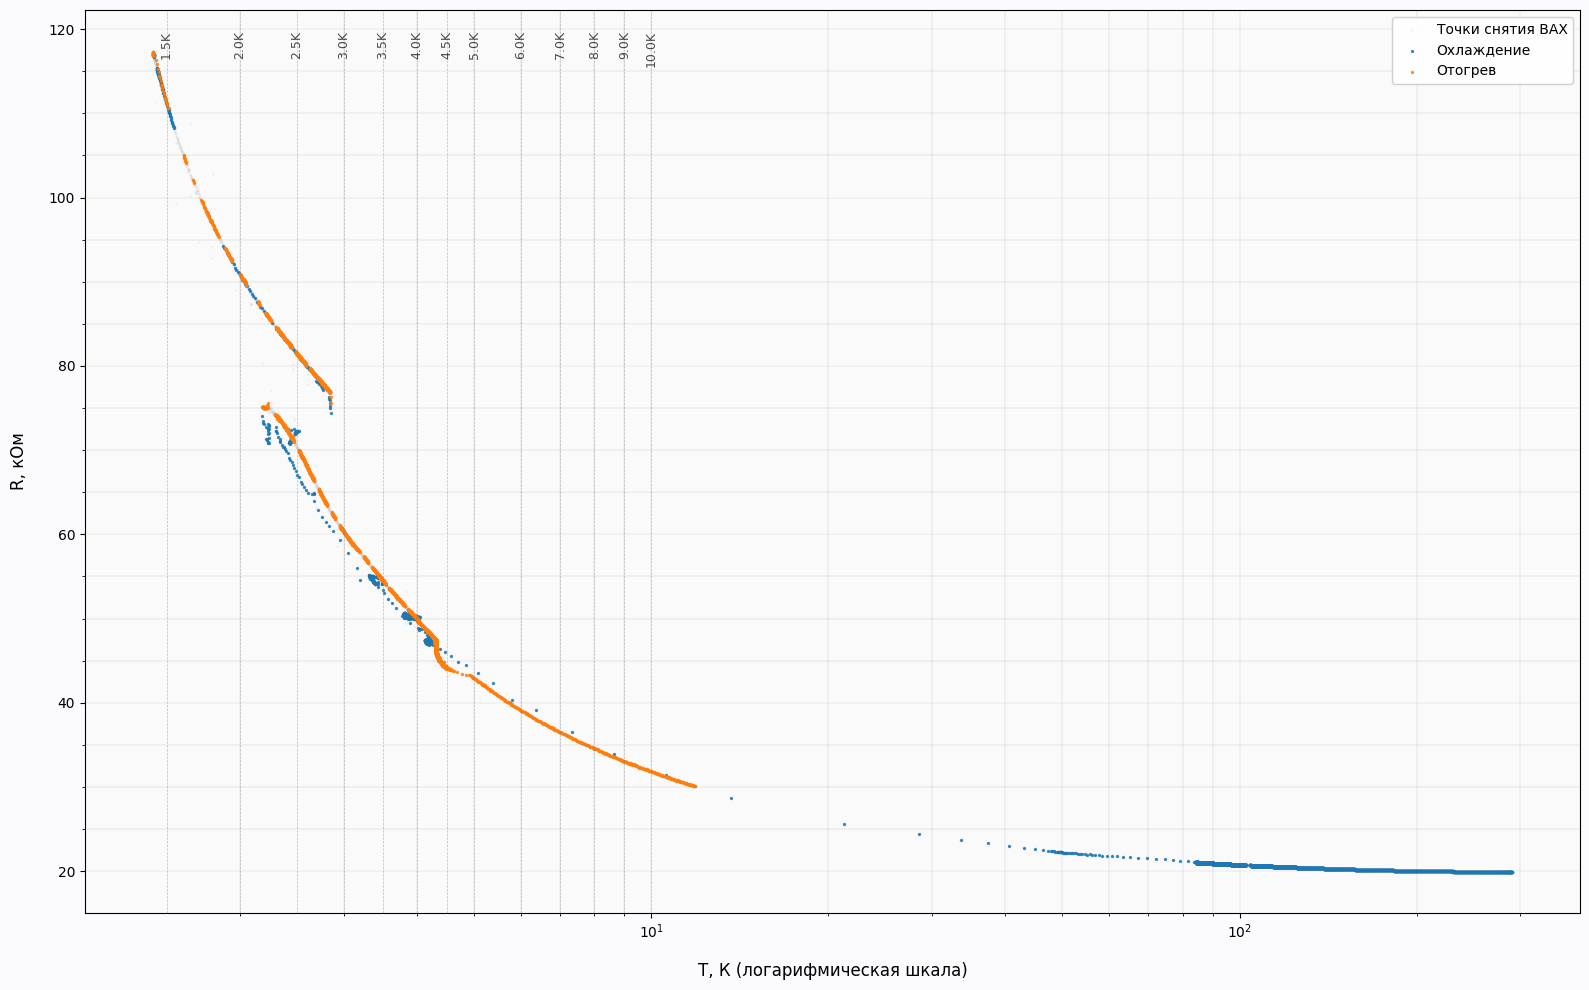


СТАТИСТИКА ФИЛЬТРАЦИИ:

Общая статистика:
  Начальное количество точек: 15145
  После фильтра NaN: 15145
  После фильтра E != 0: 14826
  После фильтра стабильности E: 13589

Статистика стабильных точек:
  Диапазон E: -1.010e-01 - 1.000e+00 В
  Среднее E: 4.087e-01 ± 4.273e-01 В
  Диапазон T: 1.42 - 290.58 K
  Диапазон R: 19.918 - 117.287 кОм
  Количество уникальных значений E: 4
  Среднее изменение E между соседями: 1.032e-04 В
  Макс изменение E между соседями: 9.000e-01 В


In [145]:
# Блок 5: График 1 - Сопротивление от температуры (логарифмическая шкала по T)
if merged_df is not None:
    plt.figure(figsize=(16, 10))
    plt.gca().set_facecolor('#FAFAFA')
    plt.gcf().set_facecolor('#FBFBFF')
    
    # Настройка сетки
    plt.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    plt.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    plt.minorticks_on()
    
    # Логарифмический масштаб по оси X
    plt.xscale('log')
    
    # Фильтруем NaN значения
    valid_data = merged_df.dropna(subset=['T_combined', 'Rs']).copy()
    
    # Фильтр 1: E != 0
    valid_data = valid_data[valid_data['E'].abs() > 1e-10].copy()
    print(f"После фильтра E != 0: {len(valid_data)} точек")
    
    # Сортируем по времени для проверки соседних точек
    valid_data = valid_data.sort_values('global_time').reset_index(drop=True)



    #valid_data = valid_data[valid_data["global_time"]<14200].reset_index()


    # Создаем маску для фильтрации по E
    mask_e_stable = np.ones(len(valid_data), dtype=bool)
    
    # Проверяем стабильность напряжения E
    for i in range(4, len(valid_data)):
    # Для E
        e_current = valid_data.loc[i, 'E']
        
        # Получаем 4 предыдущих значения
        prev_indices = [i-1, i-2, i-3, i-4]
        prev_values = []
        
        for idx in prev_indices:
            if idx >= 0:  # Проверяем, что индекс существует
                prev_values.append(valid_data.loc[idx, 'E'])
        
        # Проверяем, совпадает ли текущее значение хотя бы с одним из 4 предыдущих
        unstable = any(abs(e_current - prev) > 0.001 for prev in prev_values)
        
        # Если не совпадает ни с одним - устанавливаем флаг unstable
        if unstable:
            #print(f"Unstable at index {i}: {e_current}")
            mask_e_stable[i] = False
    
    # Применяем фильтр только по E
    stable_data = valid_data[mask_e_stable].copy()
    unstable_data = valid_data[~mask_e_stable].copy()
    
    print(f"\nФильтрация завершена:")
    print(f"Всего точек после E != 0: {len(valid_data)}")
    print(f"Стабильные точки (E не меняется > 0.01 В между соседями): {len(stable_data)}")
    print(f"Нестабильные точки: {len(unstable_data)}")
    print(f"Отфильтровано: {len(valid_data) - len(stable_data)} точек ({((len(valid_data) - len(stable_data)) / len(valid_data) * 100):.1f}%)")
    
    # Рисуем нестабильные точки (светлым цветом)
    if len(unstable_data) > 0:
        plt.scatter(unstable_data['T_combined'], unstable_data['Rs'], 
                   c='lightgray', s=1, alpha=0.2, label=f'Точки снятия ВАХ')
    
    # Рисуем стабильные точки (основной цвет)
    if len(stable_data) > 0:
        plt.scatter(stable_data[stable_data["global_time"]<14200]['T_combined'], stable_data[stable_data["global_time"]<14200]['Rs'], 
                    s=2, alpha=0.8, label=f'Охлаждение')
        plt.scatter(stable_data[stable_data["global_time"]>14200]['T_combined'], stable_data[stable_data["global_time"]>14200]['Rs'], 
                    s=2, alpha=0.8, label=f'Отогрев')
    
        # Скользящее среднее для визуализации тренда
        sorted_stable = stable_data.sort_values('T_combined')
        # if len(sorted_stable) > 10:
        #     window_size = min(50, len(sorted_stable) // 20)
            
        #     plt.plot(sorted_stable['T_combined'], 
        #             sorted_stable['Rs'].rolling(window=window_size, center=True).mean(),
        #             color='blue', linewidth=2.5, 
        #             label=f'Скользящее среднее (окно={window_size})')
    
    #plt.title(f"1. Сопротивление от температуры\nСтабильные точки по E: {len(stable_data)} из {len(valid_data)}", 
    #          fontsize=14, pad=20)
    plt.xlabel('T, К (логарифмическая шкала)', fontsize=12, labelpad=15)
    plt.ylabel('R, кОм', fontsize=12, labelpad=15)
    
    # Характерные температуры
    characteristic_temps = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
    
    if len(stable_data) > 0:
        T_min = stable_data['T_combined'].min()
        T_max = stable_data['T_combined'].max()
        
        for temp in characteristic_temps:
            if temp >= T_min and temp <= T_max:
                plt.axvline(x=temp, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
                plt.text(temp, plt.ylim()[1]*0.98, f'{temp}K', 
                        rotation=90, fontsize=9, alpha=0.7, ha='center', va='top')
    
    plt.legend(loc='best', frameon=True, framealpha=0.9, fontsize=10)
    plt.tight_layout()
    
    # Сохранение
    output_filename = 'RvsT.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\nГрафик 1 сохранен как: {output_filename}")
    plt.show()
    
    # Статистика по фильтрации
    print("\n" + "="*60)
    print("СТАТИСТИКА ФИЛЬТРАЦИИ:")
    print("="*60)
    
    if len(valid_data) > 0:
        print(f"\nОбщая статистика:")
        print(f"  Начальное количество точек: {len(merged_df)}")
        print(f"  После фильтра NaN: {len(merged_df.dropna(subset=['T_combined', 'Rs']))}")
        print(f"  После фильтра E != 0: {len(valid_data)}")
        print(f"  После фильтра стабильности E: {len(stable_data)}")
        
        if len(stable_data) > 0:
            print(f"\nСтатистика стабильных точек:")
            print(f"  Диапазон E: {stable_data['E'].min():.3e} - {stable_data['E'].max():.3e} В")
            print(f"  Среднее E: {stable_data['E'].mean():.3e} ± {stable_data['E'].std():.3e} В")
            print(f"  Диапазон T: {stable_data['T_combined'].min():.2f} - {stable_data['T_combined'].max():.2f} K")
            print(f"  Диапазон R: {stable_data['Rs'].min():.3f} - {stable_data['Rs'].max():.3f} кОм")
            print(f"  Количество уникальных значений E: {stable_data['E'].nunique()}")
            
            # Проверяем, насколько стабильно E в стабильных точках
            e_diffs = []
            for i in range(1, len(stable_data)):
                e_diffs.append(abs(stable_data.iloc[i]['E'] - stable_data.iloc[i-1]['E']))
            
            if e_diffs:
                print(f"  Среднее изменение E между соседями: {np.mean(e_diffs):.3e} В")
                print(f"  Макс изменение E между соседями: {np.max(e_diffs):.3e} В")
        
        print("="*60)

In [149]:
unstable_data[unstable_data["T_combined"]<2]

,t,E,Ux,U0,Ug,Pg,Uk,Pk,TQ,Rs,RX_h1,Tsvp,Tgaz,T_combined,original_t,global_time,file_index,file_name
7735,229.598,0.0210,-0.018234,-0.022968,0.104750,10.100,0.096156,9.607,-1.924457e-07,94.749820,94.749820,1.852216,1.330424,1.852216,229.598,13794.585,2,1542.dat
7736,231.322,0.0210,-0.018285,-0.022971,0.102930,9.917,0.094385,9.430,-1.924692e-07,95.001690,95.001690,1.843660,1.306111,1.843660,231.322,13796.309,2,1542.dat
7737,233.041,0.0210,-0.018301,-0.022950,0.101190,9.743,0.092676,9.259,-1.922949e-07,95.171516,95.171516,1.835341,1.283002,1.835341,233.041,13798.028,2,1542.dat
7738,234.822,0.0420,-0.009353,-0.011720,0.099371,9.561,0.090809,9.073,-9.819941e-08,95.241913,95.241913,1.826234,1.258837,1.826234,234.822,13799.809,2,1542.dat
7739,236.546,0.0420,-0.009396,-0.011695,0.097665,9.391,0.089103,8.902,-9.798911e-08,95.891066,95.891066,1.817805,1.236272,1.817805,236.546,13801.533,2,1542.dat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8266,1167.608,-0.0485,-0.047283,-0.061969,0.127450,12.369,0.126300,12.622,-5.192174e-07,91.066088,91.066088,1.990562,1.632511,1.990562,1167.608,14732.595,2,1542.dat
8267,1169.455,0.1000,0.016969,0.022252,0.127820,12.406,0.126680,12.659,1.864390e-07,91.015270,91.015270,1.992182,1.637447,1.992182,1169.455,14734.442,2,1542.dat
8268,1171.173,0.1000,0.016962,0.022247,0.128090,12.433,0.127020,12.693,1.864039e-07,90.995436,90.995436,1.993669,1.641049,1.993669,1171.173,14736.160,2,1542.dat
8269,1172.894,0.1000,0.016966,0.022260,0.128380,12.462,0.127380,12.729,1.865136e-07,90.961188,90.961188,1.995243,1.644918,1.995243,1172.894,14737.881,2,1542.dat


In [213]:
min(valid_data['T_combined'])

1.4216811953268516

Построение R и T от времени: 13589 точек из 3 файлов
Общая длительность: 25701.3 с

Объединенный график сохранен как: R_and_T.pdf


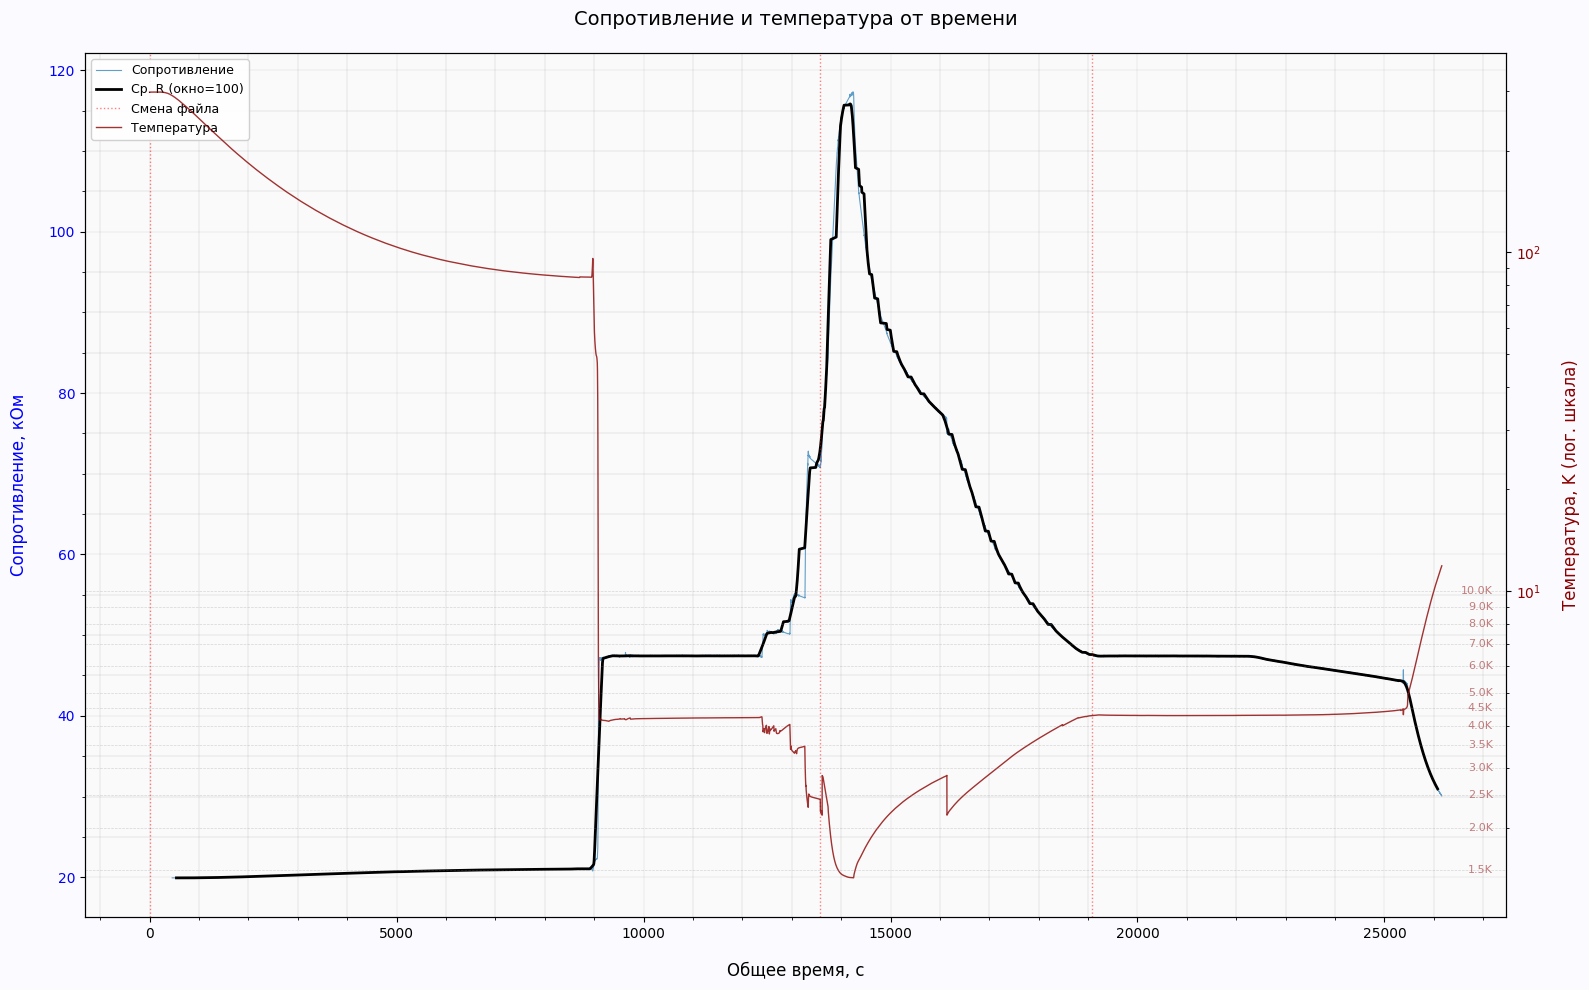


СТАТИСТИКА ПО ФАЙЛАМ:

           Файл  Точек Время начала Время конца Длительность      R мин      R макс  R среднее
       1155.dat   7237      458.7 с   13568.1 с    13109.4 с 19.918 кОм  72.799 кОм 29.607 кОм
       1542.dat   2321    13569.1 с   19026.1 с     5456.9 с 47.574 кОм 117.287 кОм 70.824 кОм
1714cropped.dat   4031    19088.5 с   26160.0 с     7071.5 с 30.075 кОм  47.579 кОм 45.453 кОм

СТАТИСТИКА ПО ТЕМПЕРАТУРЕ:
  Минимальная температура: 1.422 K
  Максимальная температура: 297.705 K
  Средняя температура: 51.156 K
  Общее время измерения: 26160.0 с


In [127]:
# Блок X: Объединенный график - Сопротивление и температура на одном графике
if merged_df is not None and not merged_df.empty:
    fig, ax1 = plt.subplots(figsize=(16, 10))
    fig.set_facecolor('#FBFBFF')
    ax1.set_facecolor('#FAFAFA')
    
    # Настройка сетки
    ax1.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    ax1.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    ax1.minorticks_on()
    
    # Сортируем по времени
    stable_data = stable_data.sort_values('global_time')
    
    print(f"Построение R и T от времени: {len(stable_data)} точек из {merged_df['file_index'].nunique()} файлов")
    print(f"Общая длительность: {stable_data['global_time'].max() - stable_data['global_time'].min():.1f} с")
    
    # ========== ОСЬ Y СЛЕВА: СОПРОТИВЛЕНИЕ ==========
    # Рисуем сопротивление разными цветами для разных файлов
    unique_files = sorted(stable_data['file_index'].unique())
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_files)))
    
    ax1.plot(stable_data['global_time'], stable_data['Rs'], 
                linewidth=0.8, alpha=0.7, label="Сопротивление")
    for file_idx, color in zip(unique_files, colors):
        file_data = stable_data[stable_data['file_index'] == file_idx]
        file_name = file_data['file_name'].iloc[0] if 'file_name' in file_data.columns else f"Файл {file_idx}"
        
        # ax1.plot(file_data['global_time'], file_data['Rs'], 
        #         color=color, linewidth=0.8, alpha=0.7, label=f"{file_name} (R)")
    
    # Добавляем скользящее среднее для сопротивления
    if len(stable_data) > 10:
        window_size = min(100, len(stable_data) // 50)
        rolling_mean = stable_data['Rs'].rolling(window=window_size, center=True).mean()
        ax1.plot(stable_data['global_time'], rolling_mean, 
                color='black', linewidth=2, label=f'Ср. R (окно={window_size})')
    
    ax1.set_xlabel('Общее время, с', fontsize=12, labelpad=15)
    ax1.set_ylabel('Сопротивление, кОм', fontsize=12, labelpad=15, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    
    # ========== ОСЬ Y СПРАВА: ТЕМПЕРАТУРА ==========
    ax2 = ax1.twinx()
    
    # Фильтруем NaN значения для температуры
    valid_data = merged_df.dropna(subset=['global_time', 'T_combined']).sort_values('global_time')
    
    # Рисуем температуру на логарифмической шкале
    ax2.plot(valid_data['global_time'], valid_data['T_combined'], 
            color='darkred', linewidth=1.0, alpha=0.8, label='Температура')
    
    # Устанавливаем логарифмическую шкалу для температуры
    ax2.set_yscale('log')
    ax2.set_ylabel('Температура, K (лог. шкала)', fontsize=12, labelpad=15, color='darkred')
    ax2.tick_params(axis='y', labelcolor='darkred')
    
    # ========== ОБЩИЕ ЭЛЕМЕНТЫ ==========
    # Добавляем вертикальные линии при смене файлов
    if len(unique_files) > 1:
        for file_idx in unique_files[1:]:  # Все кроме первого
            file_start_time = stable_data[stable_data['file_index'] == file_idx]['global_time'].min()
            ax1.axvline(x=file_start_time, color='red', linestyle=':', 
                       linewidth=1, alpha=0.5)
        ax1.axvline(x=0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Смена файла')
    
    # Горизонтальные линии для характерных температур
    characteristic_temps = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
    T_min = valid_data['T_combined'].min()
    T_max = valid_data['T_combined'].max()
    
    for temp in characteristic_temps:
        if temp >= T_min and temp <= T_max:
            ax2.axhline(y=temp, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
            # Подписываем справа
            ax2.text(ax1.get_xlim()[1]*0.99, temp, f'{temp}K', 
                    fontsize=8, alpha=0.5, ha='right', va='center', color='darkred')
    
    # Заголовок
    plt.title(f"Сопротивление и температура от времени", 
              fontsize=14, pad=20)
    
    # Объединяем легенды с двух осей
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, 
               loc='upper left', frameon=True, framealpha=0.9, fontsize=9)
    
    plt.tight_layout()
    
    # Сохранение
    output_filename = 'R_and_T.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"\nОбъединенный график сохранен как: {output_filename}")
    plt.show()
    
    # ========== СТАТИСТИКА ==========
    print("\n" + "="*60)
    print("СТАТИСТИКА ПО ФАЙЛАМ:")
    print("="*60)
    
    file_stats = []
    for file_idx in unique_files:
        file_data = stable_data[stable_data['file_index'] == file_idx]
        if len(file_data) > 0:
            file_name = file_data['file_name'].iloc[0] if 'file_name' in file_data.columns else f"Файл {file_idx}"
            stats = {
                'Файл': file_name,
                'Точек': len(file_data),
                'Время начала': f"{file_data['global_time'].min():.1f} с",
                'Время конца': f"{file_data['global_time'].max():.1f} с",
                'Длительность': f"{file_data['global_time'].max() - file_data['global_time'].min():.1f} с",
                'R мин': f"{file_data['Rs'].min():.3f} кОм",
                'R макс': f"{file_data['Rs'].max():.3f} кОм",
                'R среднее': f"{file_data['Rs'].mean():.3f} кОм",
            }
            file_stats.append(stats)
    
    if file_stats:
        stats_df = pd.DataFrame(file_stats)
        print("\n" + stats_df.to_string(index=False))
    
    print("\n" + "="*60)
    print("СТАТИСТИКА ПО ТЕМПЕРАТУРЕ:")
    print("="*60)
    print(f"  Минимальная температура: {valid_data['T_combined'].min():.3f} K")
    print(f"  Максимальная температура: {valid_data['T_combined'].max():.3f} K")
    print(f"  Средняя температура: {valid_data['T_combined'].mean():.3f} K")
    print(f"  Общее время измерения: {valid_data['global_time'].max() - valid_data['global_time'].min():.1f} с")
    print("="*60)

График 2 сохранен как: combined_plot2_time_logT.pdf


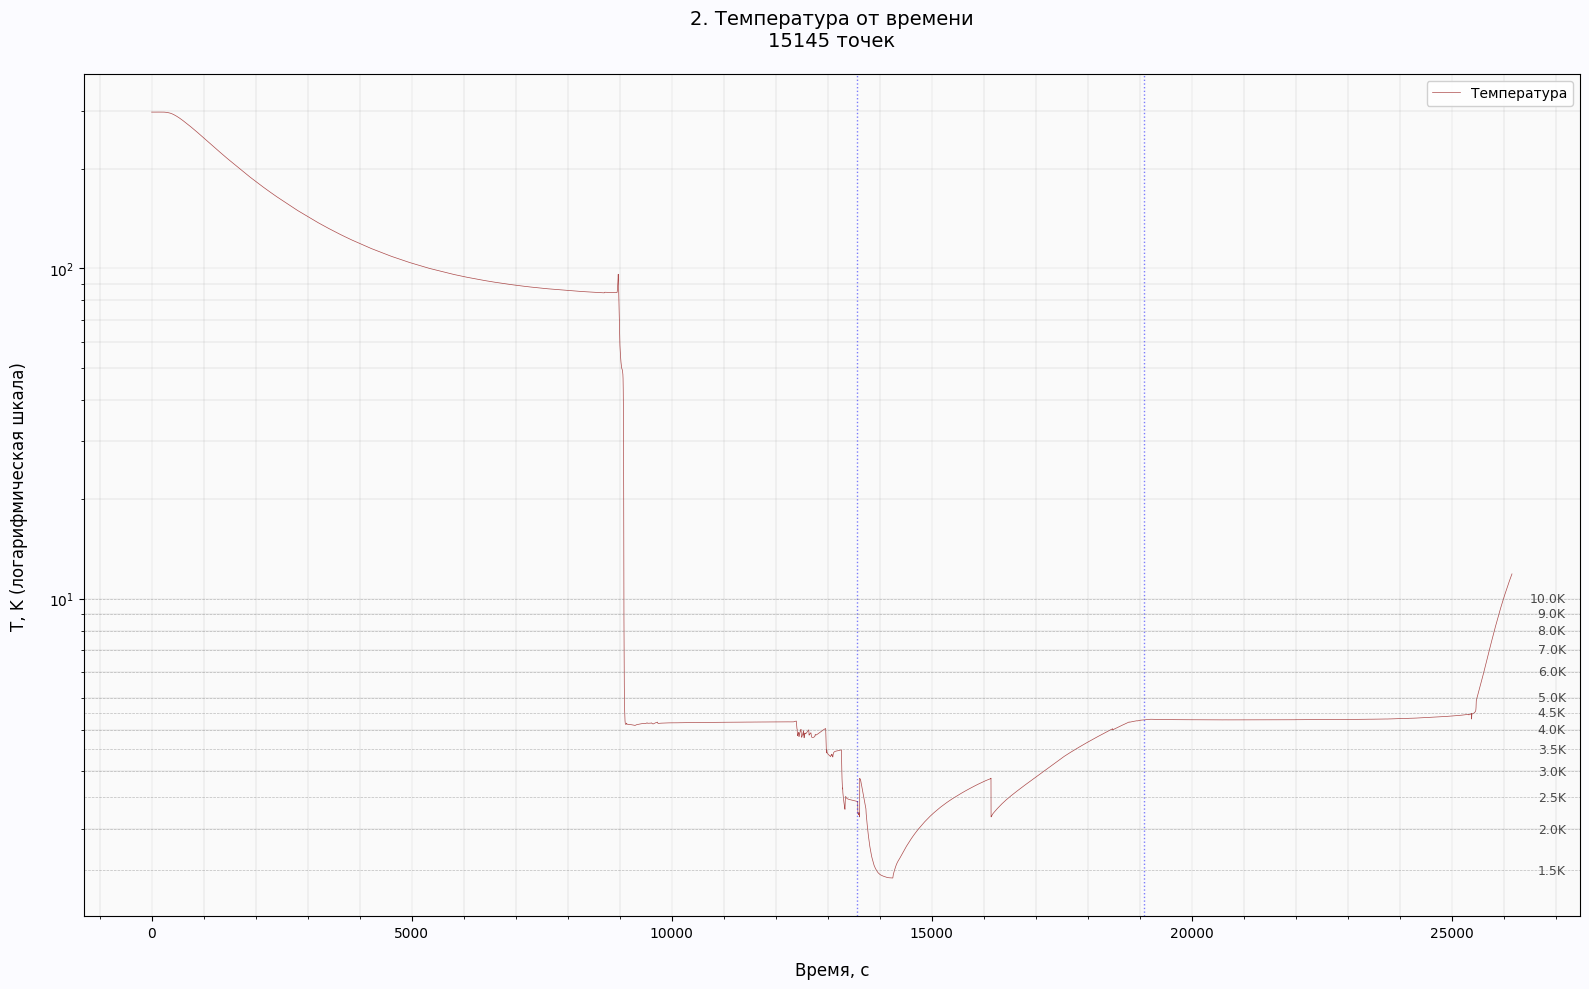

In [105]:
# Блок 6: График 2 - Температура от времени (логарифмическая шкала по Y)
if merged_df is not None:
    plt.figure(figsize=(16, 10))
    plt.gca().set_facecolor('#FAFAFA')
    plt.gcf().set_facecolor('#FBFBFF')
    
    # Настройка сетки
    plt.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    plt.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    plt.minorticks_on()
    
    # Логарифмический масштаб по оси Y
    plt.yscale('log')
    
    # Фильтруем NaN значения
    valid_data = merged_df.dropna(subset=['global_time', 'T_combined'])
    
    # Рисуем все данные
    plt.plot(valid_data['global_time'], valid_data['T_combined'], 
            color='darkred', linewidth=0.5, alpha=0.7, label='Температура')
    
    # Добавляем точки изменения файлов (если файлов больше одного)
    if merged_df['file_index'].nunique() > 1:
        file_changes = merged_df.groupby('file_index')['global_time'].first().iloc[1:]
        for change_time in file_changes:
            plt.axvline(x=change_time, color='blue', linestyle=':', 
                       linewidth=1, alpha=0.5)
    
    plt.title(f"2. Температура от времени\n{len(valid_data)} точек", 
              fontsize=14, pad=20)
    plt.xlabel('Время, с', fontsize=12, labelpad=15)
    plt.ylabel('T, K (логарифмическая шкала)', fontsize=12, labelpad=15)
    
    # Характерные температуры
    characteristic_temps = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
    T_min = valid_data['T_combined'].min()
    T_max = valid_data['T_combined'].max()
    
    for temp in characteristic_temps:
        if temp >= T_min and temp <= T_max:
            plt.axhline(y=temp, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
            plt.text(plt.xlim()[1]*0.99, temp, f'{temp}K', 
                    fontsize=9, alpha=0.7, ha='right', va='center')
    
    plt.legend(loc='best', frameon=True, framealpha=0.9, fontsize=10)
    plt.tight_layout()
    
    output_filename = 'combined_plot2_time_logT.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"График 2 сохранен как: {output_filename}")
    plt.show()
    print("="*60)

График температур сохранен как: temperatures.pdf


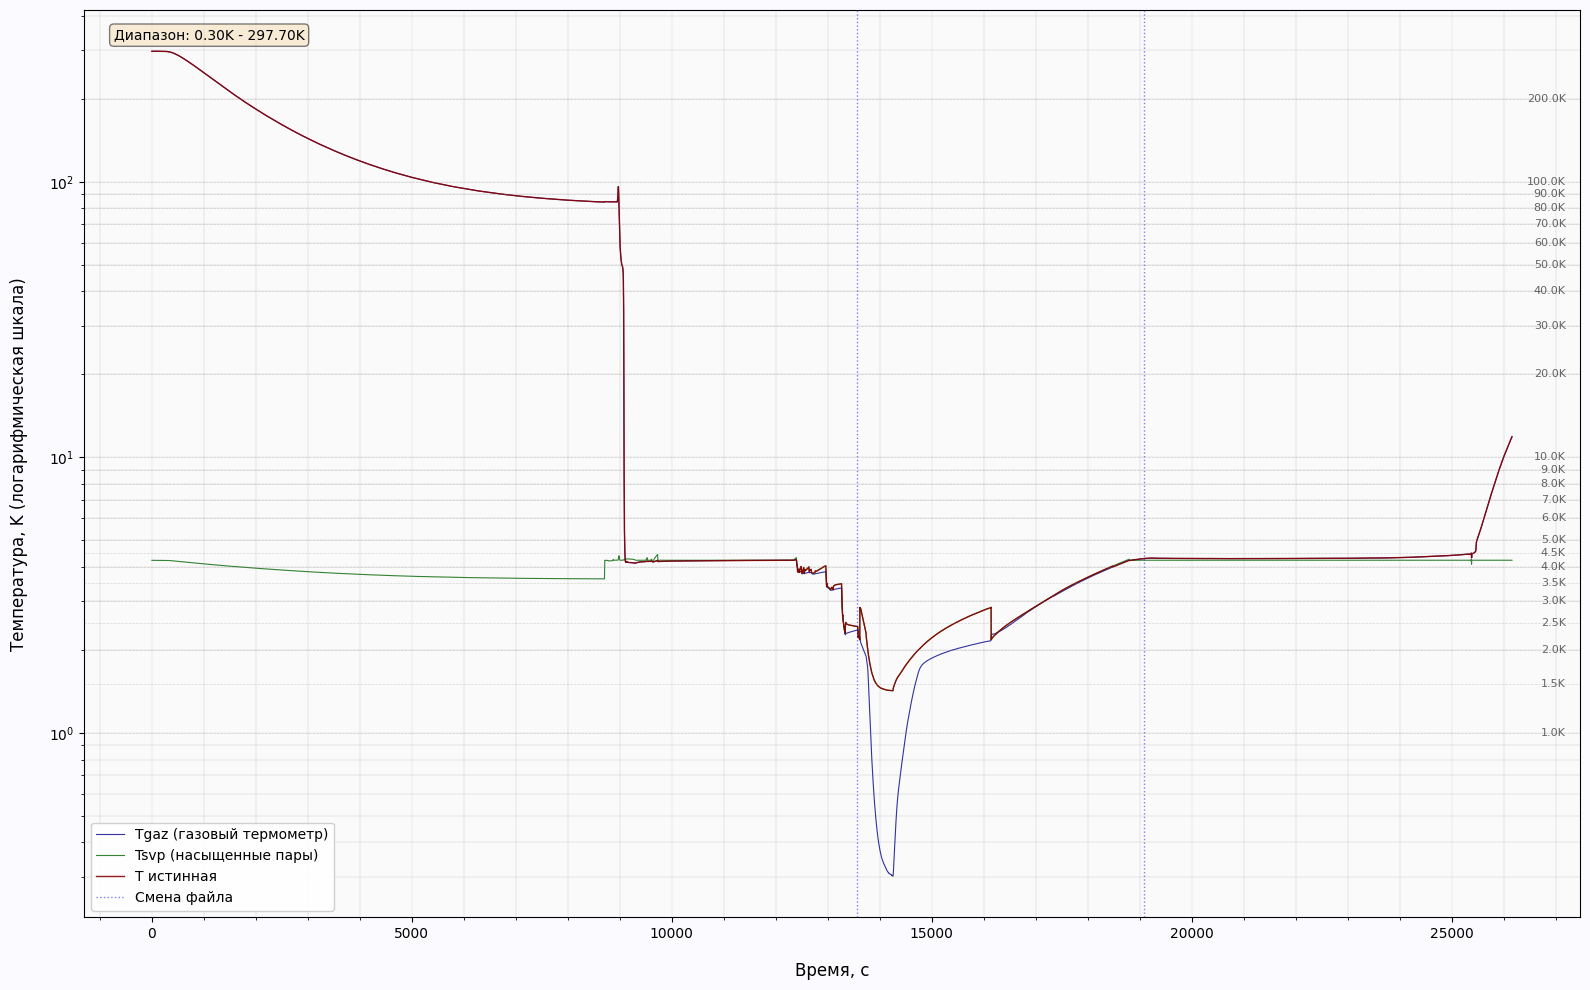

In [214]:
# Блок 6: График 2 - Все температуры от времени (логарифмическая шкала по Y)
if merged_df is not None:
    plt.figure(figsize=(16, 10))
    plt.gca().set_facecolor('#FAFAFA')
    plt.gcf().set_facecolor('#FBFBFF')
    
    # Настройка сетки
    plt.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    plt.grid(True, which='minor', linestyle='-', linewidth=0.2, color='#111111', alpha=0.3)
    plt.minorticks_on()
    
    # Логарифмический масштаб по оси Y
    plt.yscale('log')
    
    # Фильтруем NaN значения для каждой температуры отдельно
    valid_data_tgaz = merged_df.dropna(subset=['global_time', 'Tgaz'])
    valid_data_tsvp = merged_df.dropna(subset=['global_time', 'Tsvp'])
    valid_data_tcombined = merged_df.dropna(subset=['global_time', 'T_combined'])
    
    # Рисуем все три температуры разными цветами
    plt.plot(valid_data_tgaz['global_time'], valid_data_tgaz['Tgaz'], 
             color='darkblue', linewidth=0.8, alpha=0.8, label='Tgaz (газовый термометр)')
    
    plt.plot(valid_data_tsvp['global_time'], valid_data_tsvp['Tsvp'], 
             color='darkgreen', linewidth=0.8, alpha=0.8, label='Tsvp (насыщенные пары)')
    
    plt.plot(valid_data_tcombined['global_time'], valid_data_tcombined['T_combined'], 
             color='darkred', linewidth=1.0, alpha=0.9, label='T истинная')
    
    # Добавляем точки изменения файлов (если файлов больше одного)
    if merged_df['file_index'].nunique() > 1:
        file_changes = merged_df.groupby('file_index')['global_time'].first().iloc[1:]
        for change_time in file_changes:
            plt.axvline(x=change_time, color='blue', linestyle=':', 
                       linewidth=1, alpha=0.5, label='Смена файла' if change_time == file_changes.iloc[0] else "")
    
    #plt.title(f"2. Температуры от времени\nВсего точек: Tgaz={len(valid_data_tgaz)}, Tsvp={len(valid_data_tsvp)}, T_combined={len(valid_data_tcombined)}", 
    #          fontsize=14, pad=20)
    plt.xlabel('Время, с', fontsize=12, labelpad=15)
    plt.ylabel('Температура, K (логарифмическая шкала)', fontsize=12, labelpad=15)
    
    # Характерные температурные уровни
    characteristic_temps = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,
                          20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0, 90.0, 100.0, 200.0, 300.0]
    
    # Находим общий диапазон температур
    all_temps = pd.concat([valid_data_tgaz['Tgaz'], valid_data_tsvp['Tsvp'], valid_data_tcombined['T_combined']])
    T_min = all_temps.min()
    T_max = all_temps.max()
    
    # Добавляем горизонтальные линии для характерных температур
    for temp in characteristic_temps:
        if temp >= T_min and temp <= T_max:
            plt.axhline(y=temp, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
            plt.text(plt.xlim()[1]*0.99, temp, f'{temp}K', 
                    fontsize=8, alpha=0.6, ha='right', va='center')
    
    # Легенда
    plt.legend(loc='best', frameon=True, framealpha=0.9, fontsize=10)
    
    # Добавляем аннотацию о диапазоне температур
    temp_range_text = f"Диапазон: {T_min:.2f}K - {T_max:.2f}K"
    plt.text(0.02, 0.98, temp_range_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    output_filename = 'temperatures.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"График температур сохранен как: {output_filename}")
    plt.show()
    print("="*60)

График 3 сохранен как: plot_pressures.pdf


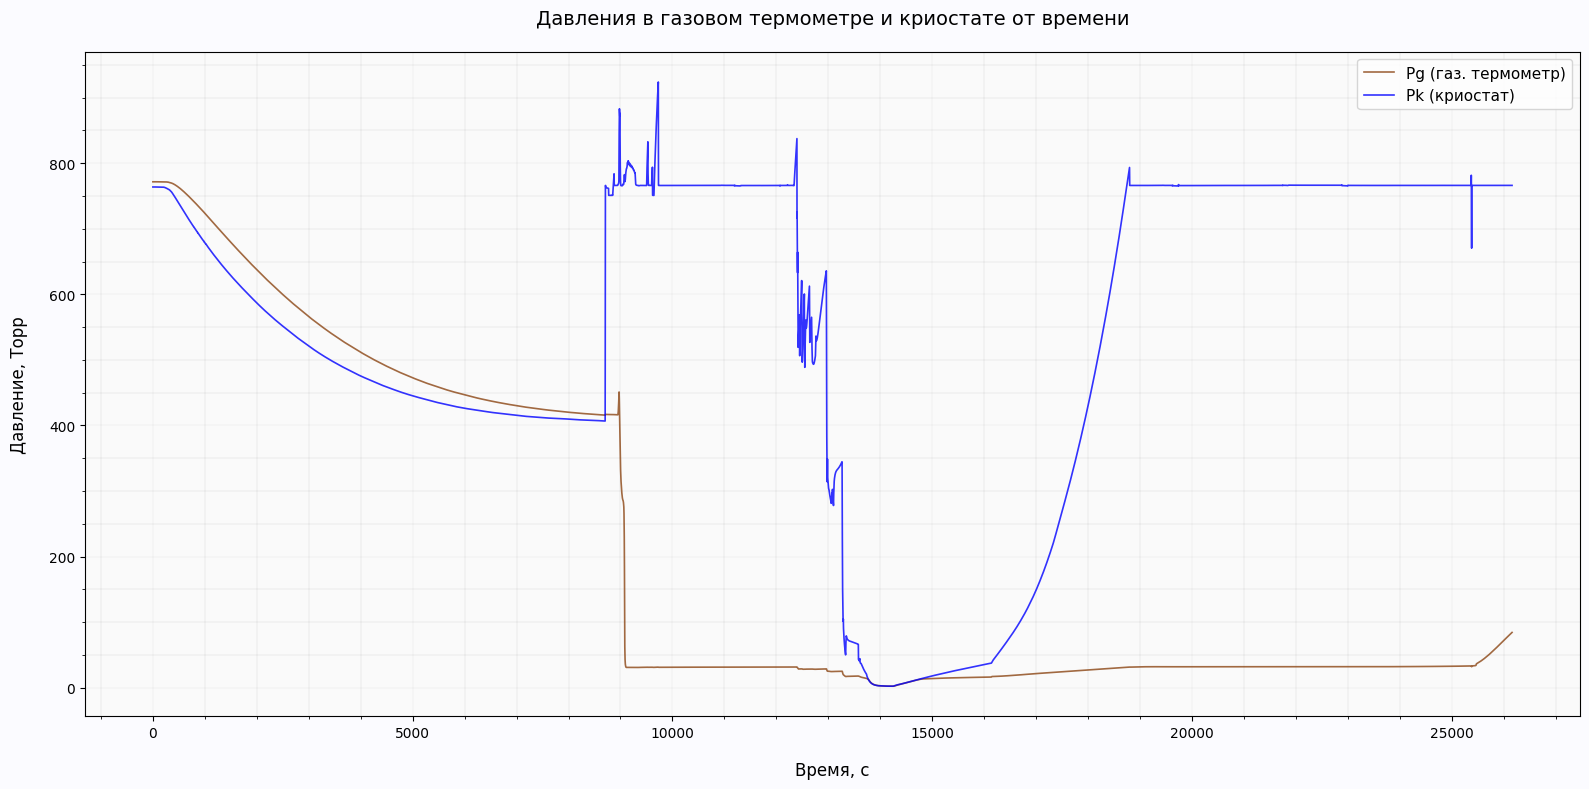

In [107]:
# Блок 7: График 3 - Давления от времени
if merged_df is not None:
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    fig.patch.set_facecolor('#FBFBFF')
    
    ax.set_facecolor('#FAFAFA')
    ax.grid(True, which='both', linestyle='-', linewidth=0.1, color='#222222', alpha=0.5)
    ax.minorticks_on()
    
    # Давление в газовом термометре
    ax.plot(merged_df['global_time'], merged_df['Pg'], 
            color='saddlebrown', linewidth=1.2, alpha=0.8, label='Pg (газ. термометр)')
    
    # Давление в криостате
    ax.plot(merged_df['global_time'], merged_df['Pk'], 
            color='blue', linewidth=1.2, alpha=0.8, label='Pk (криостат)')
    
    ax.set_xlabel('Время, с', fontsize=12, labelpad=15)
    ax.set_ylabel('Давление, Торр', fontsize=12, labelpad=15)
    ax.set_title('Давления в газовом термометре и криостате от времени', fontsize=14, pad=20)
    ax.legend(loc='best', fontsize=11)
    
    # Настройка внешнего вида
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # Добавляем сетку для лучшей читаемости
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    output_filename = 'plot_pressures.pdf'
    plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"График 3 сохранен как: {output_filename}")
    plt.show()
    print("="*60)

In [203]:
print(unstable_data[unstable_data["T_combined"] >1].loc[unstable_data["T_combined"] < 1.5, ["T_combined", "global_time", 'E']])


      T_combined  global_time      E
7889    1.443001    14064.224  0.021
7890    1.441939    14065.947  0.021
7891    1.442184    14067.666  0.021
7892    1.442021    14069.448  0.042
7893    1.441447    14071.172  0.042
7894    1.440955    14072.890  0.042
7895    1.440545    14074.671  0.063
7896    1.440380    14076.394  0.063
7897    1.439887    14078.112  0.063
7898    1.439804    14079.893  0.084
7899    1.439475    14081.616  0.084
7900    1.439310    14083.335  0.084
7901    1.438980    14085.119  0.105
7902    1.438649    14086.844  0.105
7903    1.438319    14088.563  0.105
7904    1.438071    14090.345  0.109
7905    1.437574    14092.069  0.109
7906    1.437159    14093.788  0.109
7907    1.437325    14095.569  0.088
7908    1.436660    14097.294  0.088
7909    1.436244    14099.012  0.088
7910    1.435494    14100.795  0.067
7911    1.435661    14102.517  0.067
7912    1.434910    14104.236  0.067
7913    1.434575    14106.017  0.046
7914    1.434575    14107.740  0.046
7

In [182]:
pd.set_option('display.max_rows', 1000)

In [154]:
merged_df

,t,E,Ux,U0,Ug,Pg,Uk,Pk,TQ,Rs,RX_h1,Tsvp,Tgaz,T_combined,original_t,global_time,file_index,file_name
0,5.151,0.0,-0.007069,-0.042383,7.72000,771.571,7.6373,763.661,-3.551119e-07,19.905587,19.905587,4.227193,297.649795,297.649795,5.151,0.000,1,1155.dat
1,6.868,0.0,-0.007074,-0.042393,7.72010,771.575,7.6372,763.655,-3.551982e-07,19.916967,19.916967,4.227185,297.654354,297.654354,6.868,1.717,1,1155.dat
2,8.586,0.0,-0.007072,-0.042404,7.72000,771.571,7.6372,763.657,-3.552928e-07,19.905552,19.905552,4.227188,297.649795,297.649795,8.586,3.435,1,1155.dat
3,10.304,0.0,-0.007075,-0.042400,7.72010,771.579,7.6372,763.660,-3.552602e-07,19.914561,19.914561,4.227192,297.658912,297.658912,10.304,5.153,1,1155.dat
4,12.021,0.0,-0.007074,-0.042379,7.72010,771.577,7.6373,763.662,-3.550825e-07,19.923199,19.923199,4.227195,297.656633,297.656633,12.021,6.870,1,1155.dat
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15140,7072.241,0.1,0.007956,0.031513,0.84199,83.818,7.6615,766.086,2.640377e-07,30.130356,30.130356,4.230570,11.792763,11.792763,7072.241,26153.130,3,1714cropped.dat
15141,7073.963,0.1,0.007949,0.031486,0.84328,83.947,7.6615,766.085,2.638123e-07,30.130322,30.130322,4.230569,11.812320,11.812320,7073.963,26154.852,3,1714cropped.dat
15142,7075.683,0.1,0.007945,0.031483,0.84465,84.084,7.6615,766.083,2.637905e-07,30.118101,30.118101,4.230566,11.833095,11.833095,7075.683,26156.572,3,1714cropped.dat
15143,7077.404,0.1,0.007939,0.031474,0.84597,84.215,7.6615,766.084,2.637109e-07,30.104250,30.104250,4.230567,11.852965,11.852965,7077.404,26158.293,3,1714cropped.dat



ПРИМЕР ИСПОЛЬЗОВАНИЯ КЛАССА ДЛЯ ПОСТРОЕНИЯ НЕСКОЛЬКИХ ВАХ

1. Добавляем ВАХ для разных температур:
Добавлена ВАХ: T ~1.5K
  Температура: 1.4338 ± 0.0050 K
  Точек: 58
  Сопротивление: 1.1640e+05 Ом
  Диапазон U: -0.0784 - 0.0239 В

Добавлена ВАХ: НT ~2K
  Температура: 1.9761 ± 0.0091 K
  Точек: 19
  Сопротивление: 9.1211e+04 Ом
  Диапазон U: -0.0688 - 0.0083 В

Добавлена ВАХ: T ~3K
  Температура: 2.8330 ± 0.0098 K
  Точек: 25
  Сопротивление: 6.2834e+04 Ом
  Диапазон U: -0.0547 - 0.0167 В

Добавлена ВАХ: T ~4K
  Температура: 3.8378 ± 0.0131 K
  Точек: 34
  Сопротивление: 5.1164e+04 Ом
  Диапазон U: -0.0477 - 0.0145 В


СТРОИМ ВСЕ ВАХ НА ОДНОМ ГРАФИКЕ:

ПОСТРОЕНИЕ 4 ВАХ НА ОДНОМ ГРАФИКЕ

График сохранен как: iv.pdf


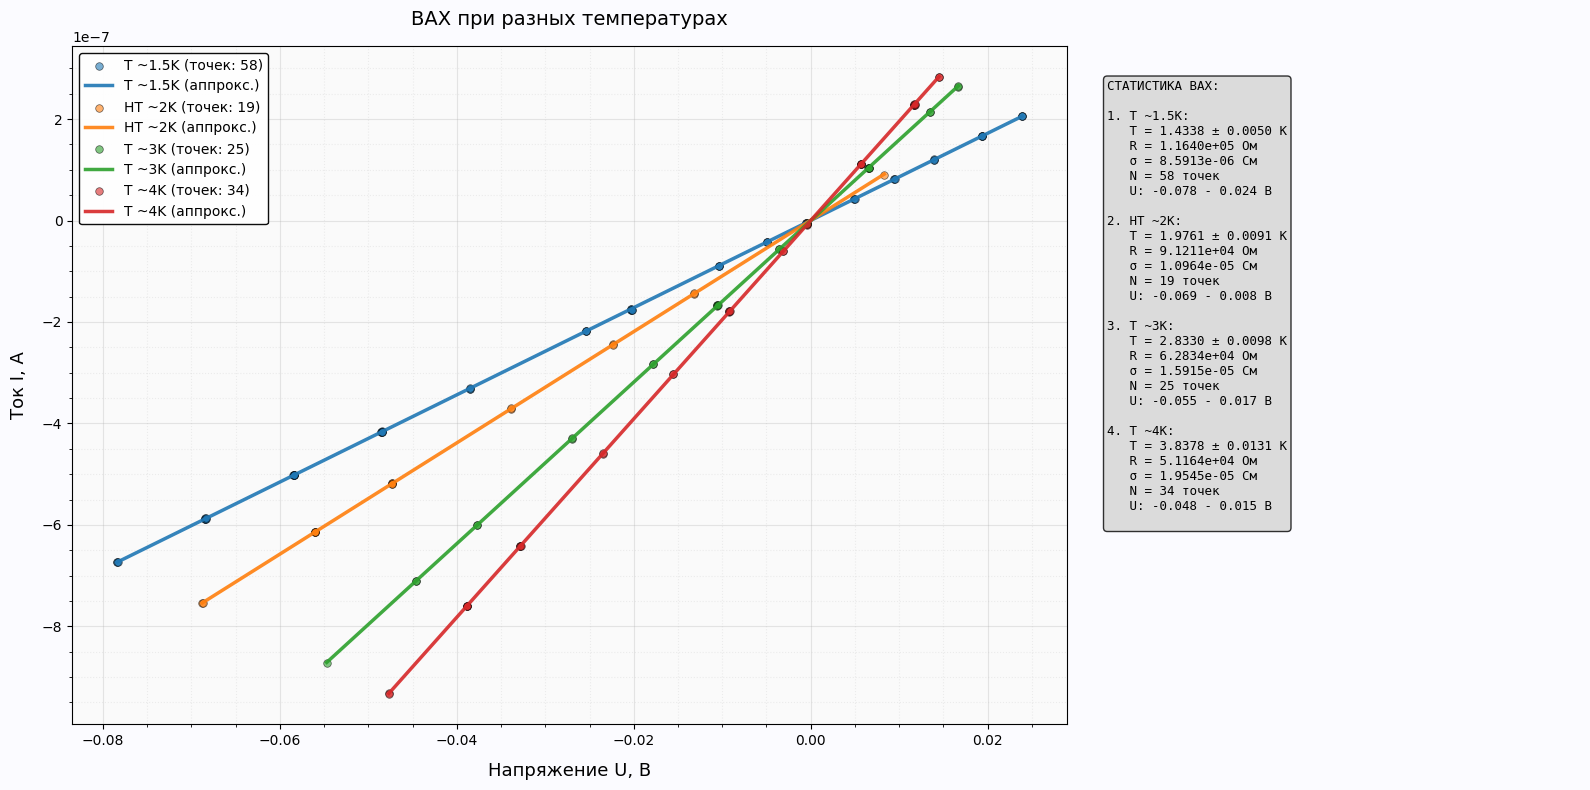


СТРОИМ ЗАВИСИМОСТЬ R(T):
График R(T) сохранен как: IvsV.pdf


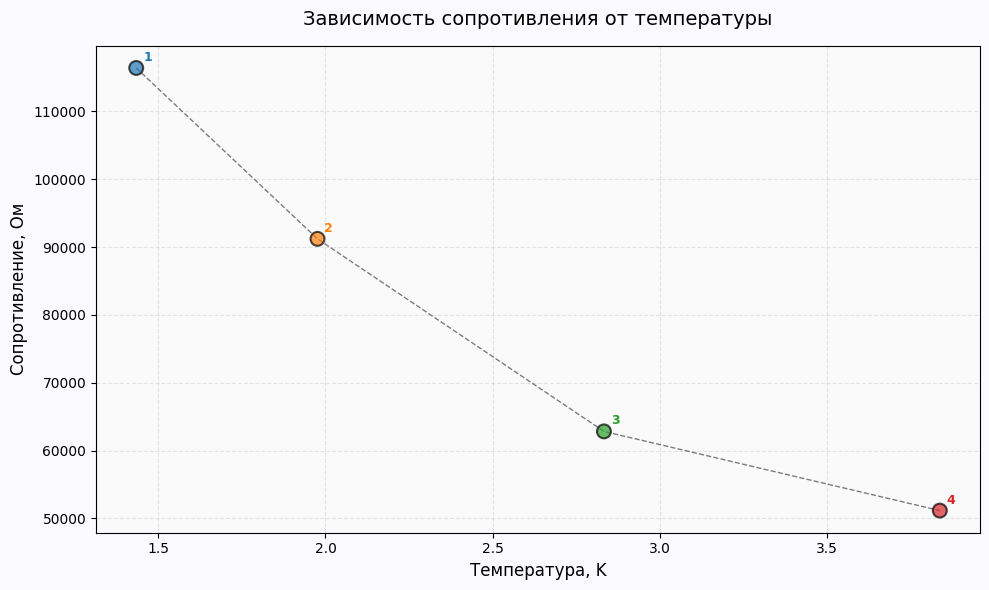

In [212]:
# Блок: Построение нескольких ВАХ на одном графике
class IVCharacteristicsPlotter:
    """
    Класс для построения нескольких ВАХ на одном графике
    """
    def __init__(self):
        self.iv_data_list = []  # Список для хранения всех ВАХ
        self.fig = None
        self.ax_main = None
        self.ax_stats = None
        self.colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Цвета для разных ВАХ
        
    def add_iv_curve(self, merged_df, label=None, target_temp=None, 
                     temp_tolerance=0.01, time_slice=None, file_index=None):
        """
        Добавить ВАХ кривую на график
        
        Параметры:
        -----------
        merged_df : DataFrame
            Основной датасет
        label : str, optional
            Метка для легенды
        target_temp : float, optional
            Целевая температура в Кельвинах
        temp_tolerance : float
            Допуск по температуре
        time_slice : tuple, optional
            Диапазон времени (начало, конец) в секундах
        file_index : int, optional
            Конкретный файл для анализа
        """
        
        if merged_df is None or merged_df.empty:
            print("Ошибка: Датафрейм пустой")
            return None
        
        # Создаем копию данных
        data = merged_df.copy()
        
        # Фильтрация
        if time_slice is not None:
            t_min, t_max = time_slice
            data = data[(data['global_time'] >= t_min) & (data['global_time'] <= t_max)]
        
        if file_index is not None:
            data = data[data['file_index'] == file_index]
        
        if data.empty:
            print("Ошибка: Нет данных после фильтрации")
            return None
        
        # Определяем целевую температуру
        if target_temp is None:
            target_temp = data['T_combined'].median()
        
        # Фильтруем по температурному диапазону
        temp_min = target_temp - temp_tolerance
        temp_max = target_temp + temp_tolerance
        
        filtered_data = data[
            (data['T_combined'] >= temp_min) & 
            (data['T_combined'] <= temp_max)
        ].copy()
        
        if filtered_data.empty:
            print(f"Ошибка: Нет данных в диапазоне {temp_min:.4f}-{temp_max:.4f} K")
            return None
        
        # Проверяем наличие необходимых колонок
        if 'Ux' not in filtered_data.columns or 'TQ' not in filtered_data.columns:
            print("Ошибка: Отсутствуют колонки U или I")
            return None
        
        # Сортируем по напряжению
        filtered_data = filtered_data.sort_values('Ux')
        
        # Вычисляем статистику
        mean_temp = filtered_data['T_combined'].mean()
        std_temp = filtered_data['T_combined'].std()
        
        # Линейная аппроксимация
        if len(filtered_data) > 1:
            z = np.polyfit(filtered_data['Ux'], filtered_data['TQ'], 1)
            p = np.poly1d(z)
            resistance = 1/z[0] if z[0] != 0 else np.inf
            conductivity = z[0]
        else:
            z = [0, 0]
            p = None
            resistance = np.inf
            conductivity = 0
        
        # Создаем метку, если не указана
        if label is None:
            file_info = f" файл {file_index}" if file_index is not None else ""
            time_info = f" t={time_slice}" if time_slice is not None else ""
            label = f"T={mean_temp:.3f}K{file_info}{time_info}"
        
        # Сохраняем данные ВАХ
        iv_data = {
            'data': filtered_data,
            'label': label,
            'mean_temp': mean_temp,
            'std_temp': std_temp,
            'resistance': resistance,
            'conductivity': conductivity,
            'poly_coeffs': z,
            'poly_func': p,
            'n_points': len(filtered_data),
            'U_range': (filtered_data['Ux'].min(), filtered_data['Ux'].max()),
            'color': self.colors[len(self.iv_data_list) % len(self.colors)]
        }
        
        self.iv_data_list.append(iv_data)
        
        print(f"Добавлена ВАХ: {label}")
        print(f"  Температура: {mean_temp:.4f} ± {std_temp:.4f} K")
        print(f"  Точек: {len(filtered_data)}")
        print(f"  Сопротивление: {resistance:.4e} Ом")
        print(f"  Диапазон U: {filtered_data['Ux'].min():.4f} - {filtered_data['Ux'].max():.4f} В")
        print()
        
        return iv_data
    
    def plot_all(self, show_scatter=True, show_fit=True, grid_on=True):
        """
        Построить все ВАХ на одном графике
        """
        if not self.iv_data_list:
            print("Нет данных для построения ВАХ")
            return
        
        print("\n" + "="*60)
        print(f"ПОСТРОЕНИЕ {len(self.iv_data_list)} ВАХ НА ОДНОМ ГРАФИКЕ")
        print("="*60)
        
        # Создаем фигуру
        self.fig, (self.ax_main, self.ax_stats) = plt.subplots(
            1, 2, figsize=(16, 8), 
            gridspec_kw={'width_ratios': [2, 1]})
        
        self.fig.set_facecolor('#FBFBFF')
        self.ax_main.set_facecolor('#FAFAFA')
        self.ax_stats.set_facecolor('#FAFAFA')
        
        # Настройка главного графика
        if grid_on:
            self.ax_main.grid(True, linestyle='-', alpha=0.3)
            self.ax_main.grid(True, which='minor', linestyle=':', alpha=0.2)
            self.ax_main.minorticks_on()
        
        # Рисуем все ВАХ
        for i, iv_data in enumerate(self.iv_data_list):
            data = iv_data['data']
            color = iv_data['color']
            label = iv_data['label']
            
            # Точечный график
            if show_scatter:
                self.ax_main.scatter(data['Ux'], data['TQ'], 
                                   color=color, s=30, alpha=0.6,
                                   edgecolors='black', linewidth=0.5,
                                   label=f"{label} (точек: {len(data)})",
                                   zorder=2)
            
            # Линейная аппроксимация
            if show_fit and iv_data['poly_func'] is not None:
                U_smooth = np.linspace(data['Ux'].min(), data['Ux'].max(), 100)
                I_smooth = iv_data['poly_func'](U_smooth)
                
                self.ax_main.plot(U_smooth, I_smooth, 
                                color=color, linewidth=2.5, alpha=0.9,
                                label=f"{label} (аппрокс.)",
                                zorder=3)
        
        self.ax_main.set_xlabel('Напряжение U, В', fontsize=13, labelpad=10)
        self.ax_main.set_ylabel('Ток I, А', fontsize=13, labelpad=10)
        self.ax_main.set_title(f'ВАХ при разных температурах', 
                              fontsize=14, pad=15)
        
        # Улучшенная легенда
        self.ax_main.legend(loc='best', fontsize=10, framealpha=0.95, 
                           edgecolor='black', fancybox=True)
        
        # Настройка графика статистики
        self.ax_stats.axis('off')
        
        # Создаем таблицу со статистикой
        stats_text = ["СТАТИСТИКА ВАХ:", ""]
        
        for i, iv_data in enumerate(self.iv_data_list):
            stats_text.append(f"{i+1}. {iv_data['label']}:")
            stats_text.append(f"   T = {iv_data['mean_temp']:.4f} ± {iv_data['std_temp']:.4f} K")
            stats_text.append(f"   R = {iv_data['resistance']:.4e} Ом")
            stats_text.append(f"   σ = {iv_data['conductivity']:.4e} См")
            stats_text.append(f"   N = {iv_data['n_points']} точек")
            stats_text.append(f"   U: {iv_data['U_range'][0]:.3f} - {iv_data['U_range'][1]:.3f} В")
            stats_text.append("")
    
        
        # Отображаем текст
        self.ax_stats.text(0.05, 0.95, '\n'.join(stats_text),
                          transform=self.ax_stats.transAxes,
                          fontsize=9,
                          family='monospace',
                          verticalalignment='top',
                          bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
        
        plt.tight_layout()
        
        # Сохранение
        output_filename = f'iv.pdf'
        plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
        print(f"\nГрафик сохранен как: {output_filename}")
        
        plt.show()
        
        return self.fig
    
    def plot_resistance_vs_temperature(self):
        """
        Дополнительный график: Зависимость сопротивления от температуры
        """
        if len(self.iv_data_list) < 2:
            print("Нужно минимум 2 ВАХ для построения зависимости R(T)")
            return
        
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.set_facecolor('#FBFBFF')
        ax.set_facecolor('#FAFAFA')
        
        ax.grid(True, linestyle='--', alpha=0.3)
        
        # Собираем данные
        temps = []
        resistances = []
        labels = []
        colors = []
        
        for iv_data in self.iv_data_list:
            if not np.isinf(iv_data['resistance']):
                temps.append(iv_data['mean_temp'])
                resistances.append(iv_data['resistance'])
                labels.append(iv_data['label'])
                colors.append(iv_data['color'])
        
        # Точечный график
        scatter = ax.scatter(temps, resistances, s=100, c=colors, 
                           alpha=0.7, edgecolors='black', linewidth=1.5, zorder=3)
        
        # Соединяем линии
        sorted_indices = np.argsort(temps)
        sorted_temps = np.array(temps)[sorted_indices]
        sorted_resistances = np.array(resistances)[sorted_indices]
        
        ax.plot(sorted_temps, sorted_resistances, 'k--', alpha=0.5, linewidth=1)
        
        # Подписи точек
        for i, (temp, res, label, color) in enumerate(zip(temps, resistances, labels, colors)):
            if len(self.iv_data_list) <= 5:  # Подписываем только если мало кривых
                ax.annotate(f"{i+1}", (temp, res), 
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=9, color=color, weight='bold')
        
        ax.set_xlabel('Температура, K', fontsize=12)
        ax.set_ylabel('Сопротивление, Ом', fontsize=12)
        ax.set_title('Зависимость сопротивления от температуры', fontsize=14, pad=15)
        
        # Логарифмическая шкала для сопротивления, если значения сильно различаются
        if max(resistances) / min(resistances) > 100:
            ax.set_yscale('log')
            ax.set_ylabel('Сопротивление, Ом (лог. шкала)', fontsize=12)
        
        plt.tight_layout()
        
        output_filename = f'IvsV.pdf'
        #plt.savefig(output_filename, format='pdf', dpi=300, bbox_inches='tight')
        print(f"График R(T) сохранен как: {output_filename}")
        
        plt.show()
        
        return fig
    
    def clear(self):
        """Очистить все сохраненные ВАХ"""
        self.iv_data_list = []
        print("Все ВАХ очищены")


# Пример использования:
print("\n" + "="*60)
print("ПРИМЕР ИСПОЛЬЗОВАНИЯ КЛАССА ДЛЯ ПОСТРОЕНИЯ НЕСКОЛЬКИХ ВАХ")
print("="*60)

# Создаем объект для построения ВАХ
iv_plotter = IVCharacteristicsPlotter()

# Пример 1: Добавление ВАХ для разных температур
print("\n1. Добавляем ВАХ для разных температур:")

# ВАХ при низкой температуре
iv_plotter.add_iv_curve(
    unstable_data,
    label="T ~1.5K",
    target_temp=1.5,
    temp_tolerance=0.1,
    time_slice=(14064, 14164),
    file_index=None
)
iv_plotter.add_iv_curve(
    unstable_data,
    label="НT ~2K",
    target_temp=1.98,
    temp_tolerance=0.02,
    time_slice=(14680, 14734),
    file_index=None
)

# ВАХ при средней температуре
iv_plotter.add_iv_curve(
    unstable_data,
    label="T ~3K",
    target_temp=2.80,
    temp_tolerance=0.05,
    time_slice=(13700, 19000),
    file_index=None
)

# ВАХ при высокой температуре
iv_plotter.add_iv_curve(
    unstable_data,
    label="T ~4K",
    target_temp=3.85,
    temp_tolerance=0.05,
    time_slice=(13700, 19000),
    file_index=None
)


print("\n" + "="*60)
print("СТРОИМ ВСЕ ВАХ НА ОДНОМ ГРАФИКЕ:")
print("="*60)

fig = iv_plotter.plot_all(
    show_scatter=True,
    show_fit=True,
    grid_on=True
)

# Дополнительный график: Зависимость сопротивления от температуры
if len(iv_plotter.iv_data_list) >= 2:
    print("\n" + "="*60)
    print("СТРОИМ ЗАВИСИМОСТЬ R(T):")
    print("="*60)
    
    iv_plotter.plot_resistance_vs_temperature()





In [158]:
# Блок 9: Сохранение данных и вывод статистики
if merged_df is not None:
    # Сохранение в CSV
    output_csv = 'combined_data.csv'
    merged_df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"Объединенные данные сохранены в: {output_csv}")
    
    # Статистика по напряжениям (проверка фильтрации)
    print("\nПроверка фильтрации напряжений (>100 В):")
    print("-" * 50)
    
    voltage_cols = ['U0', 'Ux', 'Ug', 'Uk']
    for col in voltage_cols:
        if col in merged_df.columns:
            n_outliers = (merged_df[col].abs() > 100).sum()
            total = len(merged_df[col])
            if total > 0:
                percent = n_outliers / total * 100
                print(f"{col}: {n_outliers} значений >100 В ({percent:.2f}% от {total})")
    
    print("\nПервые 5 строк данных:")
    display(merged_df.head())
    
    print("\nОсновные столбцы (первые 10 строк):")
    main_cols = ['global_time', 'Pg', 'Pk', 'T_combined', 'Rs', 'U0', 'Ux']
    display(merged_df[main_cols].head(10))
    
    print("="*60)
    print("ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО!")

Объединенные данные сохранены в: combined_data.csv

Проверка фильтрации напряжений (>100 В):
--------------------------------------------------
U0: 0 значений >100 В (0.00% от 15145)
Ux: 0 значений >100 В (0.00% от 15145)
Ug: 0 значений >100 В (0.00% от 15145)
Uk: 0 значений >100 В (0.00% от 15145)

Первые 5 строк данных:


,t,E,Ux,U0,Ug,Pg,Uk,Pk,TQ,Rs,RX_h1,Tsvp,Tgaz,T_combined,original_t,global_time,file_index,file_name
0,5.151,0.0,-0.007069,-0.042383,7.7200,771.571,7.6373,763.661,-3.551119e-07,19.905587,19.905587,4.227193,297.649795,297.649795,5.151,0.000,1,1155.dat
1,6.868,0.0,-0.007074,-0.042393,7.7201,771.575,7.6372,763.655,-3.551982e-07,19.916967,19.916967,4.227185,297.654354,297.654354,6.868,1.717,1,1155.dat
2,8.586,0.0,-0.007072,-0.042404,7.7200,771.571,7.6372,763.657,-3.552928e-07,19.905552,19.905552,4.227188,297.649795,297.649795,8.586,3.435,1,1155.dat
3,10.304,0.0,-0.007075,-0.042400,7.7201,771.579,7.6372,763.660,-3.552602e-07,19.914561,19.914561,4.227192,297.658912,297.658912,10.304,5.153,1,1155.dat
4,12.021,0.0,-0.007074,-0.042379,7.7201,771.577,7.6373,763.662,-3.550825e-07,19.923199,19.923199,4.227195,297.656633,297.656633,12.021,6.870,1,1155.dat



Основные столбцы (первые 10 строк):


,global_time,Pg,Pk,T_combined,Rs,U0,Ux
0,0.000,771.571,763.661,297.649795,19.905587,-0.042383,-0.007069
1,1.717,771.575,763.655,297.654354,19.916967,-0.042393,-0.007074
2,3.435,771.571,763.657,297.649795,19.905552,-0.042404,-0.007072
3,5.153,771.579,763.660,297.658912,19.914561,-0.042400,-0.007075
4,6.870,771.577,763.662,297.656633,19.923199,-0.042379,-0.007074
5,8.587,771.579,763.660,297.658912,19.914723,-0.042395,-0.007074
6,10.305,771.587,763.661,297.668030,19.918149,-0.042393,-0.007075
7,12.023,771.590,763.660,297.671449,19.924916,-0.042393,-0.007077
8,13.740,771.590,763.663,297.671449,19.918032,-0.042385,-0.007074
9,15.460,771.589,763.664,297.670309,19.919031,-0.042394,-0.007075


ОБРАБОТКА ЗАВЕРШЕНА УСПЕШНО!
